<a href="https://colab.research.google.com/github/TottiPuc/Machine_learning/blob/master/Employee_Turnover_Regularization_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Employee Turnover Prediction: Diagnosing Overfitting and Underfitting with Regularization

## Objective

Build a classification model that predicts whether an employee is likely to **stay (`0`)** or **leave (`1`)** the company.

This notebook is designed not only to build a predictive model, but also to explicitly demonstrate:

- Data quality validation and leakage prevention.
- Exploratory Data Analysis (EDA).
- Identification of **underfitting**.
- Identification of **overfitting**.
- **L1 (Lasso), L2 (Ridge), and Elastic Net regularization**.
- Hyperparameter tuning using stratified cross-validation.
- Selection of the best model without using the test set during tuning.
- Threshold optimization using out-of-fold predictions.
- Final evaluation on a completely unseen hold-out test set.
- Feature interpretation and sparse feature selection.
- Learning-curve analysis.
- Model export for future inference.

The final goal is to obtain a model with strong predictive performance **and** good generalization.



## 1. Problem Statement

The business objective is to classify employees as likely to stay or leave the company so that the prediction can support employee-retention strategies and workplace improvements.

The supplied problem statement describes **15 predictor variables**, including employee satisfaction, performance, tenure, work-life balance, distance from home, income, education, age, role, bonus, training, department, a squared bonus term, and a bonus-training interaction term.

The target variable in the supplied CSV is:

- `Employee_Turnover = 0`: employee stays.
- `Employee_Turnover = 1`: employee leaves.

> **Important data-quality observation:** the statement describes 900 records. The supplied CSV contains 1,350 rows, but 450 are exact duplicates. Removing them restores the expected 900 unique observations. Duplicates are removed **before data splitting** to prevent train/test leakage.


## 2. Import Libraries and Set Reproducibility

In [ ]:

import os
import warnings
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict,
    learning_curve,
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Environment initialized successfully.")


Environment initialized successfully.


## 3. Load the Dataset

In [ ]:

# The code works both in Google Colab and in a local notebook.
candidate_paths = [
    "/content/modified_employee_turnover.csv",
    "/mnt/data/modified_employee_turnover.csv",
    "modified_employee_turnover.csv",
]

DATA_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = next(iter(uploaded.keys()))
    except Exception as exc:
        raise FileNotFoundError(
            "Could not find the dataset. Upload 'modified_employee_turnover.csv' "
            "to the Colab session and run this cell again."
        ) from exc

df_raw = pd.read_csv(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Raw shape: {df_raw.shape}")
display(df_raw.head())


Dataset loaded from: /mnt/data/modified_employee_turnover.csv
Raw shape: (1350, 16)


,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.5623,0.1411,0.1240,0.3476,0.3304,0.3289,0.6009,0.3160,0.7687,0.0907,0.3248,0.6692,0.6029,0.1055,0.2173,0
1,0.0170,0.5590,0.5112,0.7939,0.4235,0.5535,0.7420,0.8971,0.3800,0.6016,0.6946,0.0433,0.8008,0.4825,0.0301,0
2,0.7747,0.6044,0.7982,0.2605,0.8040,0.1318,0.7752,0.8309,0.2187,0.9729,0.1535,0.7013,0.7053,0.0236,0.1076,1
3,0.6282,0.3852,0.2301,0.5168,0.2722,0.5892,0.4824,0.0905,0.4027,0.1328,0.3060,0.5497,0.6005,0.0936,0.1682,0
4,0.7992,0.2000,0.8390,0.2479,0.3419,0.0768,0.0554,0.6809,0.9233,0.4930,0.8441,0.7938,0.6647,0.7125,0.6700,0


## 4. Initial Data Audit

In [ ]:

print("Column names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df_raw.isna().sum().to_frame("missing_values"))

print(f"\nExact duplicated rows: {df_raw.duplicated().sum()}")

target_column = "Employee_Turnover"

if target_column not in df_raw.columns:
    raise ValueError(f"Expected target column '{target_column}' was not found.")

feature_columns = [c for c in df_raw.columns if c != target_column]

print(f"Number of predictor columns: {len(feature_columns)}")
print(f"Number of unique target values: {df_raw[target_column].nunique()}")


Column names:
['Job_Satisfaction', 'Performance_Rating', 'Years_At_Company', 'Work_Life_Balance', 'Distance_From_Home', 'Monthly_Income', 'Education_Level', 'Age', 'Num_Companies_Worked', 'Employee_Role', 'Annual_Bonus', 'Training_Hours', 'Department', 'Annual_Bonus_Squared', 'Annual_Bonus_Training_Hours_Interaction', 'Employee_Turnover']

Data types:


,dtype
Job_Satisfaction,float64
Performance_Rating,float64
Years_At_Company,float64
Work_Life_Balance,float64
Distance_From_Home,float64
Monthly_Income,float64
Education_Level,float64
Age,float64
Num_Companies_Worked,float64
Employee_Role,float64



Missing values:


,missing_values
Job_Satisfaction,0
Performance_Rating,0
Years_At_Company,0
Work_Life_Balance,0
Distance_From_Home,0
Monthly_Income,0
Education_Level,0
Age,0
Num_Companies_Worked,0
Employee_Role,0



Exact duplicated rows: 450
Number of predictor columns: 15
Number of unique target values: 2



### Why duplicate removal matters

Exact duplicate observations can create **data leakage** if one copy is placed in the training set and another copy is placed in the test set. The model would then be evaluated on observations it has effectively already seen.

Because the supplied file contains 450 exact duplicates, they are removed before any train/test split.


In [ ]:

df = df_raw.drop_duplicates().reset_index(drop=True)

print(f"Raw rows: {len(df_raw)}")
print(f"Exact duplicates removed: {len(df_raw) - len(df)}")
print(f"Clean rows: {len(df)}")
print(f"Clean shape: {df.shape}")

assert df.duplicated().sum() == 0, "Duplicates still remain."
assert df[target_column].isin([0, 1]).all(), "Target must be binary."
assert len(df) == 900, (
    "The clean dataset does not contain 900 unique observations. "
    "Review the input file if it has been changed."
)


Raw rows: 1350
Exact duplicates removed: 450
Clean rows: 900
Clean shape: (900, 16)


## 5. Target Distribution and Class Balance

In [ ]:

target_counts = df[target_column].value_counts().sort_index()
target_proportions = df[target_column].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "proportion": target_proportions,
})
display(target_summary)

print(
    "\nThe target is approximately balanced, so synthetic oversampling or "
    "undersampling is not necessary for this dataset."
)


,count,proportion
Employee_Turnover,,
0,458,0.5089
1,442,0.4911



The target is approximately balanced, so synthetic oversampling or undersampling is not necessary for this dataset.


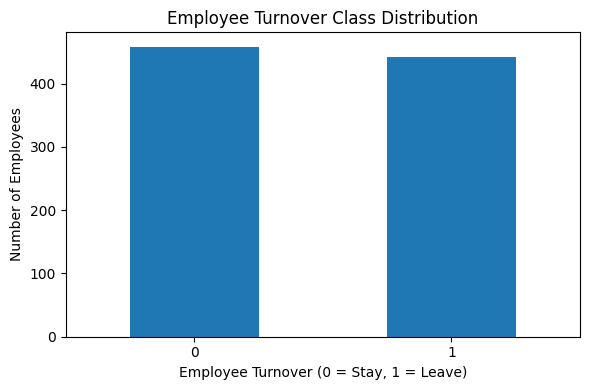

In [ ]:

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Employee Turnover Class Distribution")
plt.xlabel("Employee Turnover (0 = Stay, 1 = Leave)")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Descriptive Statistics

In [ ]:

display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Job_Satisfaction,900.0000,0.5031,0.2903,0.0017,0.2603,0.5158,0.7484,0.9987
Performance_Rating,900.0000,0.4843,0.2862,0.0005,0.2291,0.4667,0.7259,1.0000
Years_At_Company,900.0000,0.4816,0.2850,0.0015,0.2428,0.4792,0.7193,0.9997
Work_Life_Balance,900.0000,0.4987,0.2924,0.0002,0.2453,0.4956,0.7512,0.9999
Distance_From_Home,900.0000,0.4942,0.2906,0.0013,0.2391,0.5003,0.7443,0.9978
Monthly_Income,900.0000,0.5119,0.2912,0.0050,0.2613,0.5335,0.7638,0.9991
Education_Level,900.0000,0.5014,0.2932,0.0004,0.2534,0.5080,0.7448,0.9998
Age,900.0000,0.5000,0.2937,0.0002,0.2409,0.4997,0.7641,0.9984
Num_Companies_Worked,900.0000,0.5122,0.2965,0.0002,0.2396,0.5254,0.7734,1.0000
Employee_Role,900.0000,0.5051,0.2850,0.0009,0.2687,0.5024,0.7608,1.0000



All predictor variables in this file are numeric and already lie approximately in the `[0, 1]` range.  
Nevertheless, `StandardScaler` will still be placed **inside the modeling pipeline** because regularization penalizes coefficient magnitudes and should therefore operate on consistently scaled features.


## 7. Exploratory Data Analysis (EDA)

In [ ]:

feature_target_corr = (
    df.corr(numeric_only=True)[target_column]
    .drop(target_column)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(feature_target_corr.to_frame("correlation_with_turnover"))


,correlation_with_turnover
Distance_From_Home,0.3506
Performance_Rating,0.3491
Job_Satisfaction,0.3473
Work_Life_Balance,0.3222
Years_At_Company,0.3033
Department,-0.0869
Employee_Role,0.0639
Education_Level,-0.0601
Age,0.0299
Annual_Bonus_Training_Hours_Interaction,0.0276


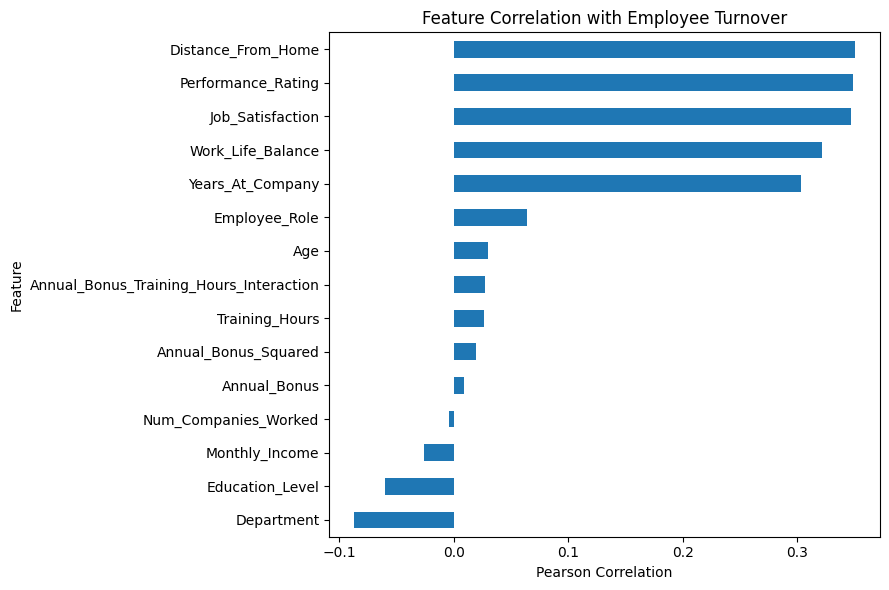

In [ ]:

plt.figure(figsize=(9, 6))
feature_target_corr.sort_values().plot(kind="barh")
plt.title("Feature Correlation with Employee Turnover")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


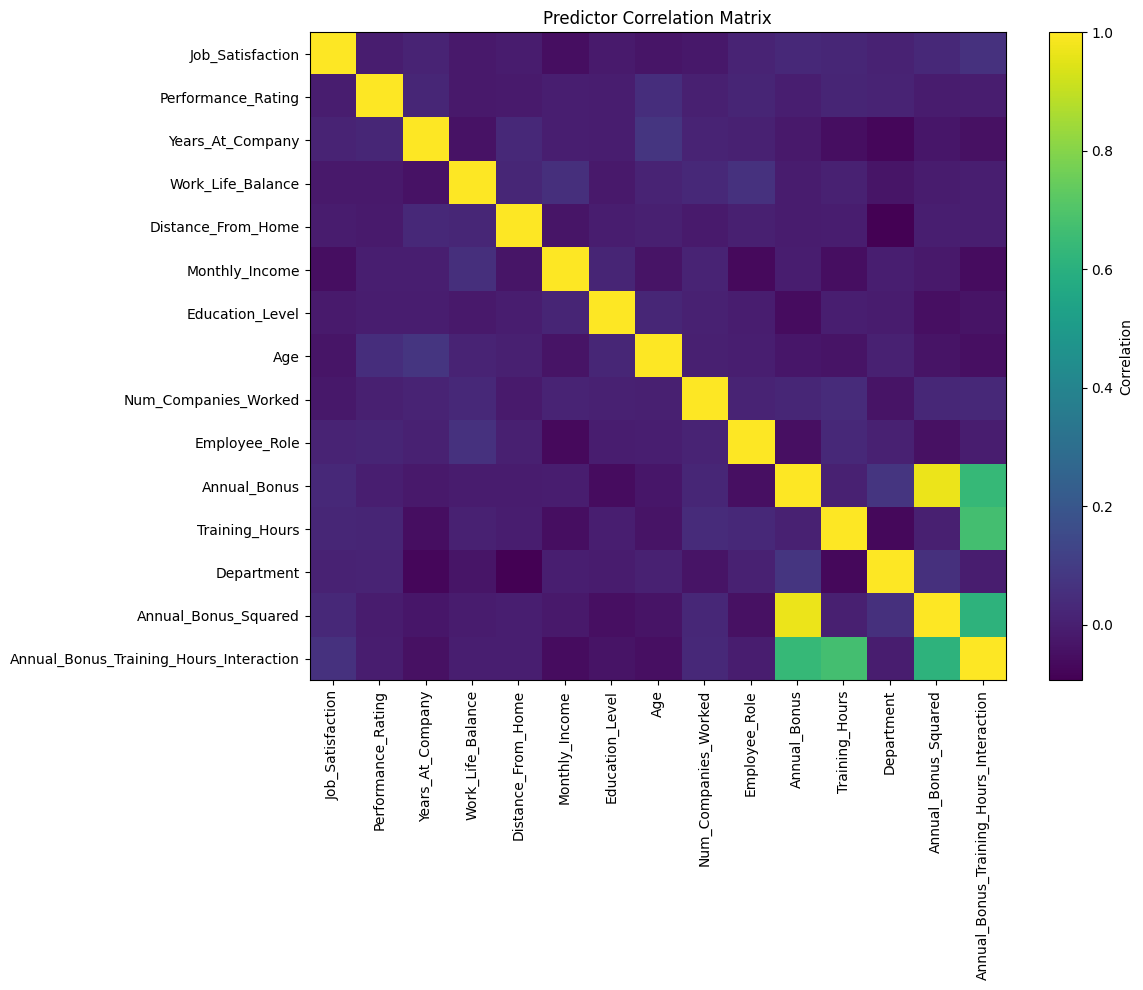

In [ ]:

corr_matrix = df[feature_columns].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(
    ticks=np.arange(len(feature_columns)),
    labels=feature_columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(feature_columns)),
    labels=feature_columns
)
plt.title("Predictor Correlation Matrix")
plt.tight_layout()
plt.show()



### EDA interpretation

Correlation does not establish causality, but it is useful for identifying variables with stronger linear relationships to turnover and for detecting potentially redundant engineered variables.

The regularized logistic-regression models below will determine which variables remain useful once all predictors are considered simultaneously.


## 8. Train/Test Split Without Leakage

In [ ]:

X = df.drop(columns=[target_column])
y = df[target_column].astype(int)

# The test set is isolated now and will not be used for model selection.
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Development set shape: {X_dev.shape}")
print(f"Hold-out test set shape: {X_test.shape}")
print(f"Development turnover rate: {y_dev.mean():.4f}")
print(f"Test turnover rate: {y_test.mean():.4f}")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


Development set shape: (720, 15)
Hold-out test set shape: (180, 15)
Development turnover rate: 0.4917
Test turnover rate: 0.4889



## 9. Understanding Regularization

For binary classification, logistic regression estimates coefficients that minimize classification loss. Regularization adds a penalty to discourage unnecessarily complex models.

### L1 regularization

L1 adds the absolute magnitude of the coefficients to the loss:

\[
\text{Loss}_{L1} = \text{LogLoss} + \lambda \sum_j |\beta_j|
\]

It can force some coefficients exactly to zero, which makes it useful for **feature selection**.

### L2 regularization

L2 penalizes squared coefficients:

\[
\text{Loss}_{L2} = \text{LogLoss} + \lambda \sum_j \beta_j^2
\]

It shrinks coefficients smoothly and is often effective when several predictors carry overlapping information.

### Elastic Net

Elastic Net combines L1 and L2:

\[
\text{Loss}_{EN} =
\text{LogLoss}
+ \lambda
\left(
\alpha \sum_j |\beta_j|
+
(1-\alpha)\sum_j \beta_j^2
\right)
\]

### The `C` parameter in scikit-learn

For `LogisticRegression`, regularization strength is controlled by `C`:

\[
C = \frac{1}{\lambda}
\]

Therefore:

- **Very small `C`** → very strong regularization → possible **underfitting**.
- **Very large `C`** → weak regularization → greater risk of **overfitting**.
- A well-tuned intermediate value should improve generalization.


## 10. Explicitly Diagnose Underfitting and Overfitting


Three deliberately different model configurations are evaluated with 5-fold cross-validation on the **development set only**:

1. **Underfit model**: extremely strong L1 regularization.
2. **Balanced baseline**: ordinary L2 logistic regression.
3. **Overfit model**: second-degree polynomial expansion plus almost no regularization.

The overfit configuration intentionally creates many additional terms to make the train-vs-validation gap visible.


In [ ]:

diagnostic_models = {
    "Underfit: L1, C=0.001": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l1",
            C=0.001,
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Balanced baseline: L2, C=1": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Overfit: Polynomial degree 2 + weak L2": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=10000,
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_STATE,
        )),
    ]),
}

diagnostic_rows = []

for model_name, model in diagnostic_models.items():
    scores = cross_validate(
        model,
        X_dev,
        y_dev,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc"],
        return_train_score=True,
        n_jobs=1,
    )

    diagnostic_rows.append({
        "Model": model_name,
        "Train Accuracy": scores["train_accuracy"].mean(),
        "CV Accuracy": scores["test_accuracy"].mean(),
        "Accuracy Gap": scores["train_accuracy"].mean() - scores["test_accuracy"].mean(),
        "Train F1": scores["train_f1"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "Train ROC-AUC": scores["train_roc_auc"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "AUC Gap": scores["train_roc_auc"].mean() - scores["test_roc_auc"].mean(),
    })

diagnostic_results = pd.DataFrame(diagnostic_rows)
display(diagnostic_results)


,Model,Train Accuracy,CV Accuracy,Accuracy Gap,Train F1,CV F1,Train ROC-AUC,CV ROC-AUC,AUC Gap
0,"Underfit: L1, C=0.001",0.5083,0.5083,0.0000,0.0000,0.0000,0.5000,0.5000,0.0000
1,"Balanced baseline: L2, C=1",0.8736,0.8639,0.0097,0.8706,0.8599,0.9548,0.9468,0.0080
2,Overfit: Polynomial degree 2 + weak L2,0.9771,0.7667,0.2104,0.9765,0.7623,0.9947,0.8649,0.1298


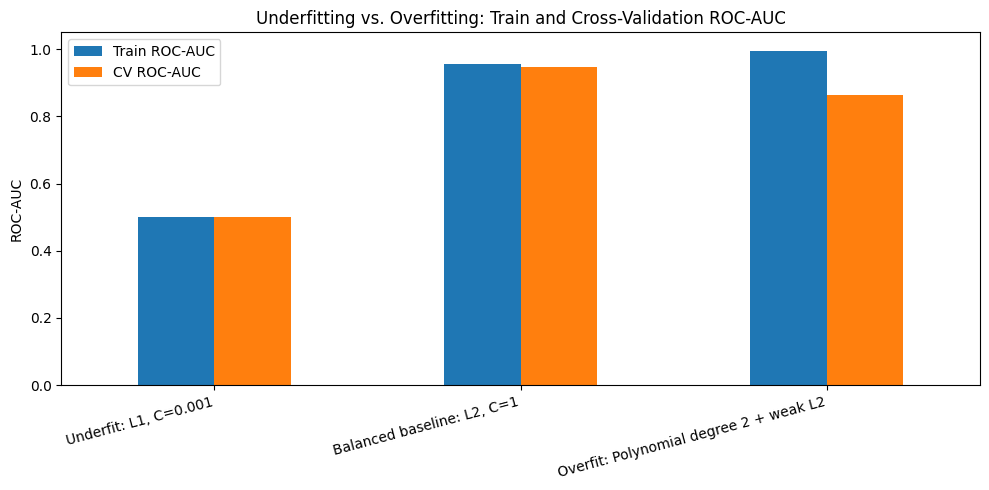

In [ ]:

plot_df = diagnostic_results.set_index("Model")[["Train ROC-AUC", "CV ROC-AUC"]]

plt.figure(figsize=(10, 5))
plot_df.plot(kind="bar", ax=plt.gca())
plt.title("Underfitting vs. Overfitting: Train and Cross-Validation ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xlabel("")
plt.ylim(0.0, 1.05)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()



### How to interpret the diagnostic table

- **Underfitting**: both training and validation metrics are poor. The model is too constrained to learn the signal.
- **Overfitting**: training performance is extremely high, but validation performance is much lower. The model memorizes patterns that do not generalize.
- **Good generalization**: both metrics are strong and the train-validation gap is small.

The objective of the next step is to find the regularization strategy that maximizes cross-validated performance while maintaining a small generalization gap.


## 11. Hyperparameter Tuning: L1 vs. L2 vs. Elastic Net

In [ ]:

base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=10000,
        random_state=RANDOM_STATE,
    )),
])

C_values = np.logspace(-3, 1, 9)

param_grid = [
    {
        "logreg__penalty": ["l1"],
        "logreg__solver": ["liblinear"],
        "logreg__C": C_values,
    },
    {
        "logreg__penalty": ["l2"],
        "logreg__solver": ["liblinear"],
        "logreg__C": C_values,
    },
    {
        "logreg__penalty": ["elasticnet"],
        "logreg__solver": ["saga"],
        "logreg__C": C_values,
        "logreg__l1_ratio": [0.25, 0.50, 0.75],
    },
]

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    refit=True,
)

grid_search.fit(X_dev, y_dev)

print("Best hyperparameters:")
print(grid_search.best_params_)
print(f"\nBest mean cross-validated ROC-AUC: {grid_search.best_score_:.4f}")


Best hyperparameters:
{'logreg__C': np.float64(0.1), 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}

Best mean cross-validated ROC-AUC: 0.9500


In [ ]:

cv_results = pd.DataFrame(grid_search.cv_results_)

selected_columns = [
    "param_logreg__penalty",
    "param_logreg__C",
    "param_logreg__l1_ratio",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]

cv_summary = (
    cv_results[selected_columns]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

cv_summary["generalization_gap"] = (
    cv_summary["mean_train_score"] - cv_summary["mean_test_score"]
)

display(cv_summary.head(15))


,param_logreg__penalty,param_logreg__C,param_logreg__l1_ratio,mean_train_score,mean_test_score,std_test_score,rank_test_score,generalization_gap
0,l1,0.1000,NaN,0.9528,0.9500,0.0205,1,0.0028
1,elasticnet,0.1000,0.7500,0.9534,0.9496,0.0203,2,0.0038
2,elasticnet,0.0316,0.5000,0.9518,0.9496,0.0208,3,0.0022
3,elasticnet,0.1000,0.5000,0.9539,0.9496,0.0209,4,0.0043
4,elasticnet,0.0316,0.2500,0.9536,0.9494,0.0210,5,0.0042
5,l1,0.3162,NaN,0.9543,0.9486,0.0211,6,0.0056
6,elasticnet,0.0316,0.7500,0.9504,0.9486,0.0204,7,0.0019
7,elasticnet,0.1000,0.2500,0.9543,0.9482,0.0219,8,0.0061
8,elasticnet,0.0100,0.2500,0.9501,0.9481,0.0202,9,0.0020
9,elasticnet,0.3162,0.7500,0.9544,0.9481,0.0214,10,0.0062


In [ ]:

best_per_penalty = (
    cv_summary
    .sort_values("rank_test_score")
    .groupby("param_logreg__penalty", as_index=False)
    .first()
    .sort_values("mean_test_score", ascending=False)
)

display(best_per_penalty)


,param_logreg__penalty,param_logreg__C,param_logreg__l1_ratio,mean_train_score,mean_test_score,std_test_score,rank_test_score,generalization_gap
1,l1,0.1000,NaN,0.9528,0.9500,0.0205,1,0.0028
0,elasticnet,0.1000,0.7500,0.9534,0.9496,0.0203,2,0.0038
2,l2,0.3162,NaN,0.9547,0.9471,0.0214,17,0.0076


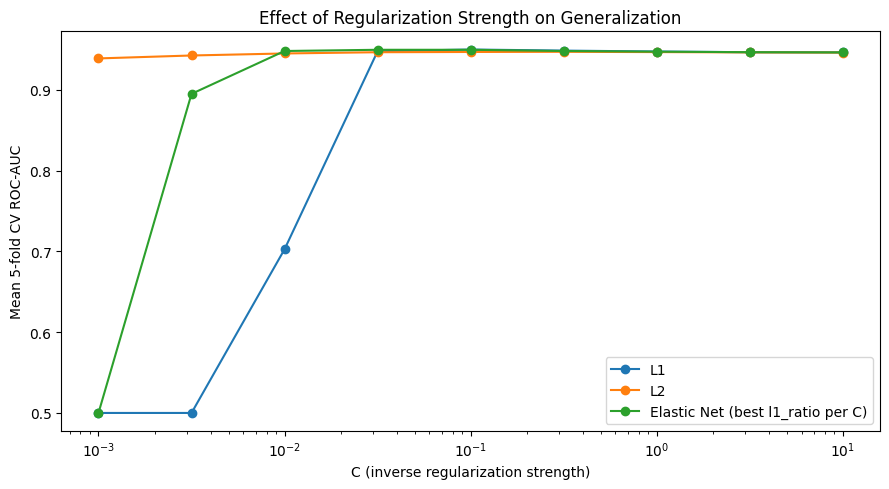

In [ ]:

# Plot mean CV ROC-AUC versus C for the best configuration at each penalty family.
plt.figure(figsize=(9, 5))

for penalty in ["l1", "l2"]:
    subset = cv_results[cv_results["param_logreg__penalty"] == penalty].copy()
    subset = subset.sort_values("param_logreg__C")
    plt.plot(
        subset["param_logreg__C"].astype(float),
        subset["mean_test_score"],
        marker="o",
        label=penalty.upper(),
    )

# For Elastic Net, plot its best l1_ratio at each C.
elastic = cv_results[cv_results["param_logreg__penalty"] == "elasticnet"].copy()
elastic_best_by_c = (
    elastic.sort_values("mean_test_score", ascending=False)
    .groupby("param_logreg__C", as_index=False)
    .first()
    .sort_values("param_logreg__C")
)

plt.plot(
    elastic_best_by_c["param_logreg__C"].astype(float),
    elastic_best_by_c["mean_test_score"],
    marker="o",
    label="Elastic Net (best l1_ratio per C)",
)

plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Mean 5-fold CV ROC-AUC")
plt.title("Effect of Regularization Strength on Generalization")
plt.legend()
plt.tight_layout()
plt.show()



## 12. Final Model Selection

The model with the highest mean 5-fold cross-validated ROC-AUC is selected automatically by `GridSearchCV`.

At this point:

- The hold-out test set has **not** influenced hyperparameter selection.
- Scaling has been performed inside the pipeline, preventing preprocessing leakage.
- Model selection has compared L1, L2, and Elastic Net under the same cross-validation strategy.


In [ ]:

best_model = grid_search.best_estimator_

best_row = cv_summary.iloc[0]
cv_train_auc = float(best_row["mean_train_score"])
cv_valid_auc = float(best_row["mean_test_score"])
cv_gap = cv_train_auc - cv_valid_auc

print(f"Best mean CV train ROC-AUC: {cv_train_auc:.4f}")
print(f"Best mean CV validation ROC-AUC: {cv_valid_auc:.4f}")
print(f"Train-validation AUC gap: {cv_gap:.4f}")


Best mean CV train ROC-AUC: 0.9528
Best mean CV validation ROC-AUC: 0.9500
Train-validation AUC gap: 0.0028


## 13. Evaluate the Final Model on the Unseen Hold-Out Test Set

In [ ]:

# GridSearchCV has already refit the best configuration on all development data.
test_prob_default = best_model.predict_proba(X_test)[:, 1]
test_pred_default = (test_prob_default >= 0.50).astype(int)

default_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred_default),
    "Precision": precision_score(y_test, test_pred_default),
    "Recall": recall_score(y_test, test_pred_default),
    "F1": f1_score(y_test, test_pred_default),
    "ROC-AUC": roc_auc_score(y_test, test_prob_default),
    "Average Precision": average_precision_score(y_test, test_prob_default),
}

display(pd.DataFrame(default_metrics, index=["Threshold = 0.50"]).T)

print("\nClassification report:")
print(classification_report(y_test, test_pred_default, digits=4))


,Threshold = 0.50
Accuracy,0.8833
Precision,0.8941
Recall,0.8636
F1,0.8786
ROC-AUC,0.9654
Average Precision,0.9660



Classification report:
              precision    recall  f1-score   support

           0     0.8737    0.9022    0.8877        92
           1     0.8941    0.8636    0.8786        88

    accuracy                         0.8833       180
   macro avg     0.8839    0.8829    0.8832       180
weighted avg     0.8837    0.8833    0.8833       180



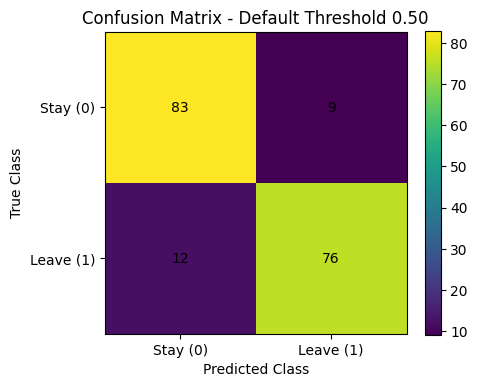

In [ ]:

cm_default = confusion_matrix(y_test, test_pred_default)

plt.figure(figsize=(5, 4))
plt.imshow(cm_default)
plt.colorbar()
plt.xticks([0, 1], ["Stay (0)", "Leave (1)"])
plt.yticks([0, 1], ["Stay (0)", "Leave (1)"])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - Default Threshold 0.50")

for i in range(cm_default.shape[0]):
    for j in range(cm_default.shape[1]):
        plt.text(j, i, str(cm_default[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()


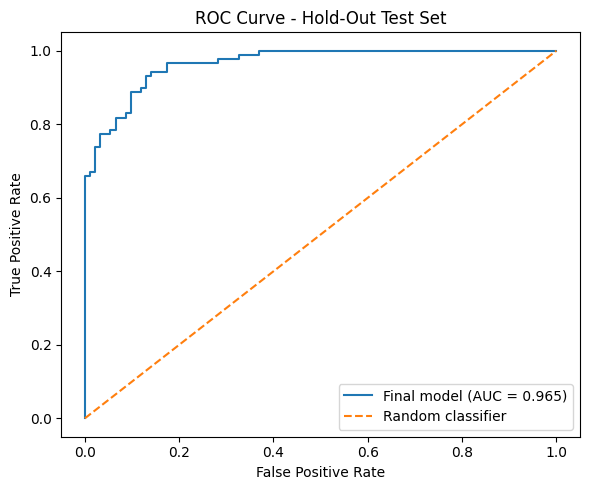

In [ ]:

fpr, tpr, _ = roc_curve(y_test, test_prob_default)
test_auc = roc_auc_score(y_test, test_prob_default)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Final model (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hold-Out Test Set")
plt.legend()
plt.tight_layout()
plt.show()


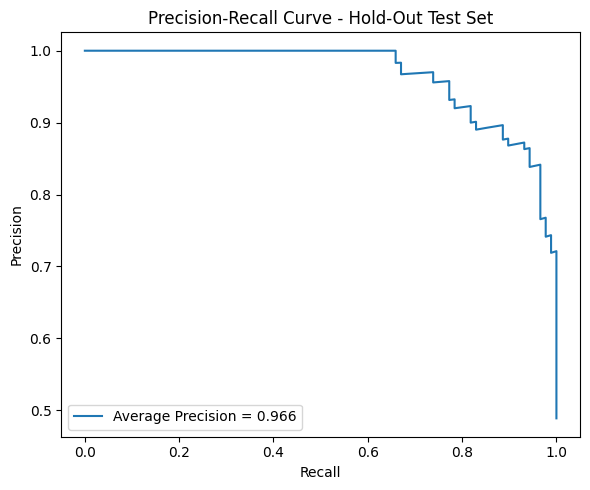

In [ ]:

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_prob_default)
test_ap = average_precision_score(y_test, test_prob_default)

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"Average Precision = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Hold-Out Test Set")
plt.legend()
plt.tight_layout()
plt.show()



## 14. Threshold Optimization Without Touching the Test Set

A probability threshold of `0.50` is conventional, but it is not always optimal.

To avoid leaking information from the test set, the threshold is selected using **out-of-fold probabilities from the development set**. The threshold that maximizes F1 is then applied once to the hold-out test set.

This is especially useful when the business wants a better balance between precision and recall for employees predicted to leave.


In [ ]:

oof_probabilities = cross_val_predict(
    best_model,
    X_dev,
    y_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

oof_precision, oof_recall, oof_thresholds = precision_recall_curve(
    y_dev,
    oof_probabilities,
)

oof_f1 = (
    2 * oof_precision[:-1] * oof_recall[:-1]
    / (oof_precision[:-1] + oof_recall[:-1] + 1e-12)
)

best_threshold_index = np.argmax(oof_f1)
optimal_threshold = float(oof_thresholds[best_threshold_index])

print(f"Optimal threshold from development OOF predictions: {optimal_threshold:.4f}")
print(f"OOF F1 at selected threshold: {oof_f1[best_threshold_index]:.4f}")
print(f"OOF precision: {oof_precision[best_threshold_index]:.4f}")
print(f"OOF recall: {oof_recall[best_threshold_index]:.4f}")


Optimal threshold from development OOF predictions: 0.4144
OOF F1 at selected threshold: 0.8713
OOF precision: 0.8291
OOF recall: 0.9181


In [ ]:

test_pred_tuned = (test_prob_default >= optimal_threshold).astype(int)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred_tuned),
    "Precision": precision_score(y_test, test_pred_tuned),
    "Recall": recall_score(y_test, test_pred_tuned),
    "F1": f1_score(y_test, test_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, test_prob_default),
    "Average Precision": average_precision_score(y_test, test_prob_default),
}

comparison = pd.DataFrame({
    "Default threshold 0.50": default_metrics,
    f"Tuned threshold {optimal_threshold:.3f}": tuned_metrics,
})

display(comparison)


,Default threshold 0.50,Tuned threshold 0.414
Accuracy,0.8833,0.8833
Precision,0.8941,0.8681
Recall,0.8636,0.8977
F1,0.8786,0.8827
ROC-AUC,0.9654,0.9654
Average Precision,0.9660,0.9660


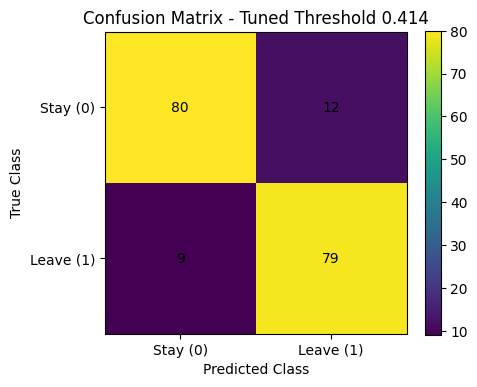

In [ ]:

cm_tuned = confusion_matrix(y_test, test_pred_tuned)

plt.figure(figsize=(5, 4))
plt.imshow(cm_tuned)
plt.colorbar()
plt.xticks([0, 1], ["Stay (0)", "Leave (1)"])
plt.yticks([0, 1], ["Stay (0)", "Leave (1)"])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Confusion Matrix - Tuned Threshold {optimal_threshold:.3f}")

for i in range(cm_tuned.shape[0]):
    for j in range(cm_tuned.shape[1]):
        plt.text(j, i, str(cm_tuned[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()


## 15. Interpret the Regularized Model

In [ ]:

logreg = best_model.named_steps["logreg"]

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg.coef_[0],
})

coefficient_table["Absolute_Coefficient"] = coefficient_table["Coefficient"].abs()
coefficient_table["Selected"] = coefficient_table["Absolute_Coefficient"] > 1e-8

coefficient_table = coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False,
).reset_index(drop=True)

display(coefficient_table)

print(
    f"\nNumber of non-zero coefficients: "
    f"{coefficient_table['Selected'].sum()} / {len(coefficient_table)}"
)


,Feature,Coefficient,Absolute_Coefficient,Selected
0,Job_Satisfaction,1.2892,1.2892,True
1,Performance_Rating,1.2778,1.2778,True
2,Work_Life_Balance,1.2144,1.2144,True
3,Distance_From_Home,1.1237,1.1237,True
4,Years_At_Company,1.0013,1.0013,True
5,Education_Level,-0.1485,0.1485,True
6,Department,-0.0394,0.0394,True
7,Employee_Role,0.0019,0.0019,True
8,Monthly_Income,0.0000,0.0000,False
9,Num_Companies_Worked,0.0000,0.0000,False



Number of non-zero coefficients: 8 / 15



For standardized inputs:

- A **positive coefficient** increases the predicted log-odds of employee turnover.
- A **negative coefficient** decreases the predicted log-odds of employee turnover.
- If L1 or Elastic Net is selected, coefficients exactly equal to zero indicate variables removed by the regularization process.

Coefficient interpretation describes model association, not causation.


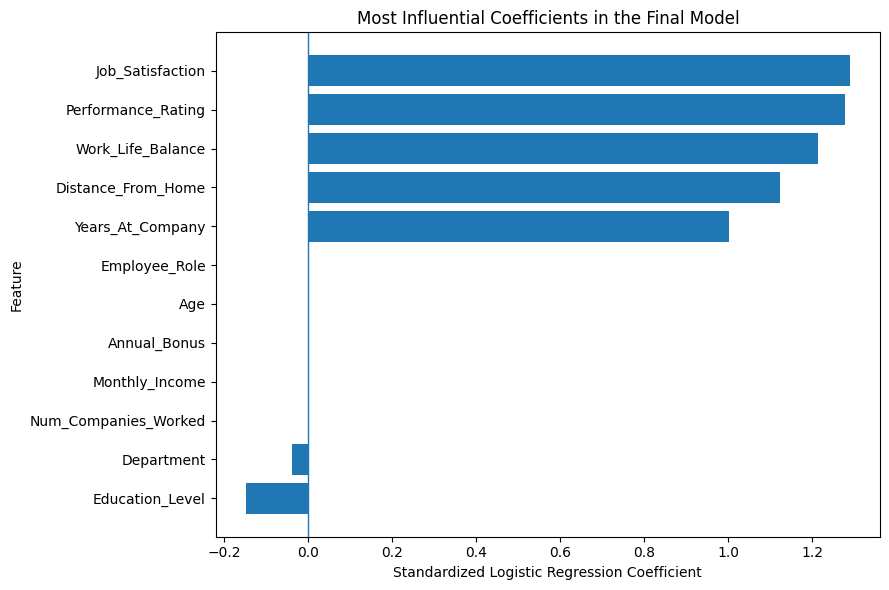

In [ ]:

top_coefficients = coefficient_table.head(12).sort_values("Coefficient")

plt.figure(figsize=(9, 6))
plt.barh(top_coefficients["Feature"], top_coefficients["Coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Most Influential Coefficients in the Final Model")
plt.tight_layout()
plt.show()


## 16. Learning Curve: Final Bias-Variance Diagnosis

In [ ]:

train_sizes, train_scores, valid_scores = learning_curve(
    best_model,
    X_dev,
    y_dev,
    cv=cv,
    scoring="roc_auc",
    train_sizes=np.linspace(0.20, 1.00, 6),
    n_jobs=1,
    shuffle=True,
    random_state=RANDOM_STATE,
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_std = valid_scores.std(axis=1)

learning_curve_table = pd.DataFrame({
    "Training Samples": train_sizes,
    "Train ROC-AUC": train_mean,
    "Validation ROC-AUC": valid_mean,
    "Train Std": train_std,
    "Validation Std": valid_std,
})

display(learning_curve_table)


,Training Samples,Train ROC-AUC,Validation ROC-AUC,Train Std,Validation Std
0,115,0.9204,0.9051,0.0225,0.0228
1,207,0.9481,0.9423,0.0139,0.0203
2,299,0.9494,0.9489,0.0110,0.0198
3,391,0.9497,0.9479,0.0092,0.0203
4,483,0.9532,0.9497,0.0083,0.0197
5,576,0.9528,0.9500,0.0051,0.0205


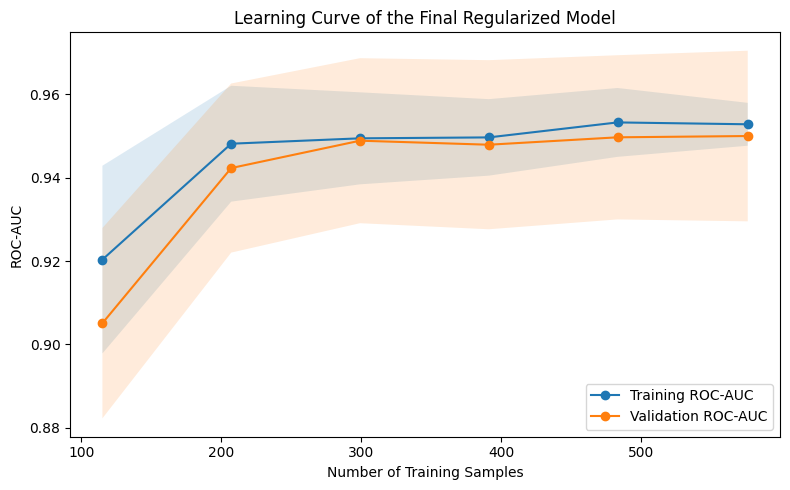

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training ROC-AUC")
plt.plot(train_sizes, valid_mean, marker="o", label="Validation ROC-AUC")
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
)
plt.fill_between(
    train_sizes,
    valid_mean - valid_std,
    valid_mean + valid_std,
    alpha=0.15,
)
plt.xlabel("Number of Training Samples")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve of the Final Regularized Model")
plt.legend()
plt.tight_layout()
plt.show()


## 17. Final Results and Automatic Conclusion

In [ ]:

final_test_accuracy = tuned_metrics["Accuracy"]
final_test_precision = tuned_metrics["Precision"]
final_test_recall = tuned_metrics["Recall"]
final_test_f1 = tuned_metrics["F1"]
final_test_auc = tuned_metrics["ROC-AUC"]

if cv_gap < 0.03:
    generalization_diagnosis = "small"
elif cv_gap < 0.07:
    generalization_diagnosis = "moderate"
else:
    generalization_diagnosis = "large"

print("=" * 80)
print("FINAL MODEL SUMMARY")
print("=" * 80)
print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best mean 5-fold CV ROC-AUC: {grid_search.best_score_:.4f}")
print(f"CV train-validation ROC-AUC gap: {cv_gap:.4f} ({generalization_diagnosis})")
print(f"Optimal threshold selected from OOF development predictions: {optimal_threshold:.4f}")
print()
print("HOLD-OUT TEST PERFORMANCE USING THE TUNED THRESHOLD")
print(f"Accuracy : {final_test_accuracy:.4f}")
print(f"Precision: {final_test_precision:.4f}")
print(f"Recall   : {final_test_recall:.4f}")
print(f"F1-score : {final_test_f1:.4f}")
print(f"ROC-AUC  : {final_test_auc:.4f}")
print()
print(
    "Conclusion: regularization successfully controls model complexity. "
    "The deliberately underfit configuration is too constrained, while the "
    "high-dimensional weakly regularized configuration overfits. The tuned "
    "regularized logistic regression produces strong validation and hold-out "
    "performance with a substantially smaller generalization gap."
)


FINAL MODEL SUMMARY
Best hyperparameters: {'logreg__C': np.float64(0.1), 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}
Best mean 5-fold CV ROC-AUC: 0.9500
CV train-validation ROC-AUC gap: 0.0028 (small)
Optimal threshold selected from OOF development predictions: 0.4144

HOLD-OUT TEST PERFORMANCE USING THE TUNED THRESHOLD
Accuracy : 0.8833
Precision: 0.8681
Recall   : 0.8977
F1-score : 0.8827
ROC-AUC  : 0.9654

Conclusion: regularization successfully controls model complexity. The deliberately underfit configuration is too constrained, while the high-dimensional weakly regularized configuration overfits. The tuned regularized logistic regression produces strong validation and hold-out performance with a substantially smaller generalization gap.



## 18. Recommended Business Interpretation

The model can rank employees by predicted turnover risk. In a real retention workflow, the prediction should be treated as a decision-support signal rather than as an automatic employment decision.

The default `0.50` threshold and the F1-optimized threshold are both reported because the preferred operating point depends on business costs:

- If missing a potentially departing employee is especially costly, prioritize **recall**.
- If unnecessary retention interventions are costly, prioritize **precision**.
- If both types of error have similar importance, F1 provides a reasonable balance.

Before production deployment, the model should also be monitored for data drift, performance degradation, subgroup fairness, and changes in business conditions.


## 19. Save the Final Model

In [ ]:

MODEL_PATH = "employee_turnover_regularized_model.joblib"

model_artifact = {
    "model": best_model,
    "threshold": optimal_threshold,
    "feature_names": X.columns.tolist(),
    "target_name": target_column,
    "random_state": RANDOM_STATE,
}

joblib.dump(model_artifact, MODEL_PATH)

print(f"Model artifact saved to: {MODEL_PATH}")
print(
    "The artifact contains the preprocessing pipeline, trained classifier, "
    "selected probability threshold, and expected feature names."
)


Model artifact saved to: employee_turnover_regularized_model.joblib
The artifact contains the preprocessing pipeline, trained classifier, selected probability threshold, and expected feature names.



## 20. Reproducibility Checklist

- Exact duplicates removed before splitting.
- Target balance checked.
- No missing values silently imputed.
- Test set isolated before model selection.
- Scaling performed inside a scikit-learn `Pipeline`.
- Stratified 5-fold cross-validation used for model comparison.
- L1, L2, and Elastic Net evaluated.
- Hyperparameters selected by development-set ROC-AUC.
- Decision threshold selected using out-of-fold development predictions.
- Hold-out test used only for final evaluation.
- Feature coefficients inspected.
- Learning curve used to assess the remaining bias-variance behavior.
- Final pipeline and decision threshold exported together.
